In [1]:
import pypsa
import gurobipy as gp

In [ ]:
import pandas as pd

def get_capital_costs_for_snapshots(row, snapshots):
    """
    row: pandas Series (from the DataFrame)
    snapshots: pd.DatetimeIndex or list of date strings
    Returns: pd.Series of capital costs for each snapshot
    """
    # Ensure snapshots are Timestamps
    snapshots = pd.to_datetime(snapshots)
    # Build financial year label for each snapshot
    years = snapshots.year
    fy_start = years.where(snapshots.month < 7, years)
    fy_end = years.where(snapshots.month < 7, years + 1)
    fy_labels = [f"{start}-{str(end)[-2:]}" for start, end in zip(fy_start, fy_end)]
    # Find all year columns in the row
    year_cols = [c for c in row.index if '-' in c and c[:4].isdigit()]
    last_col = year_cols[-1]
    # For each snapshot, get the matching column or use last_col
    cost_cols = []
    for label in fy_labels:
        found = [c for c in year_cols if label in c]
        cost_cols.append(found[0] if found else last_col)
    # Build the cost series
    costs = pd.Series([row[c] for c in cost_cols], index=snapshots)
    return costs
 
# Example usage:
df = pd.read_csv("../isp_sheets_23/build_costs/SC_regional_build_costs_tech.csv")
row = df.iloc[0]
snapshots = pd.date_range("2024-07-01", "2025-06-30", freq="6h")  # Financial years
costs = get_capital_costs_for_snapshots(row, snapshots)
print(costs)

2024-07-01 00:00:00    1538.0
2024-07-01 06:00:00    1538.0
2024-07-01 12:00:00    1538.0
2024-07-01 18:00:00    1538.0
2024-07-02 00:00:00    1538.0
                        ...  
2025-06-29 00:00:00     617.0
2025-06-29 06:00:00     617.0
2025-06-29 12:00:00     617.0
2025-06-29 18:00:00     617.0
2025-06-30 00:00:00     617.0
Freq: 6h, Length: 1457, dtype: float64


In [3]:
network = pypsa.Network()

In [193]:
0.5*52*30/60

13.0

=== Error Metrics ===
MSE:  7128.83
RMSE: 84.43
MAE:  68.78

=== Block Summary ===
Block  1:   1- 14, mean= 1236.7 MW, weight= 7.0 h
Block  2:  15- 32, mean=  946.6 MW, weight= 9.0 h
Block  3:  33- 48, mean= 1468.9 MW, weight= 8.0 h
Block  4:  49- 62, mean= 1192.2 MW, weight= 7.0 h
Block  5:  63- 79, mean=  792.8 MW, weight= 8.5 h
Block  6:  80-149, mean= 1321.6 MW, weight=35.0 h
Block  7: 150-176, mean= 1055.0 MW, weight=13.5 h
Block  8: 177-194, mean= 1358.2 MW, weight= 9.0 h
Block  9: 195-209, mean= 1138.0 MW, weight= 7.5 h
Block 10: 210-221, mean=  885.1 MW, weight= 6.0 h
Block 11: 222-251, mean= 1265.8 MW, weight=15.0 h
Block 12: 252-272, mean=  911.9 MW, weight=10.5 h
Block 13: 273-300, mean= 1246.0 MW, weight=14.0 h
Block 14: 301-319, mean=  713.4 MW, weight= 9.5 h
Block 15: 320-335, mean= 1264.6 MW, weight= 8.0 h


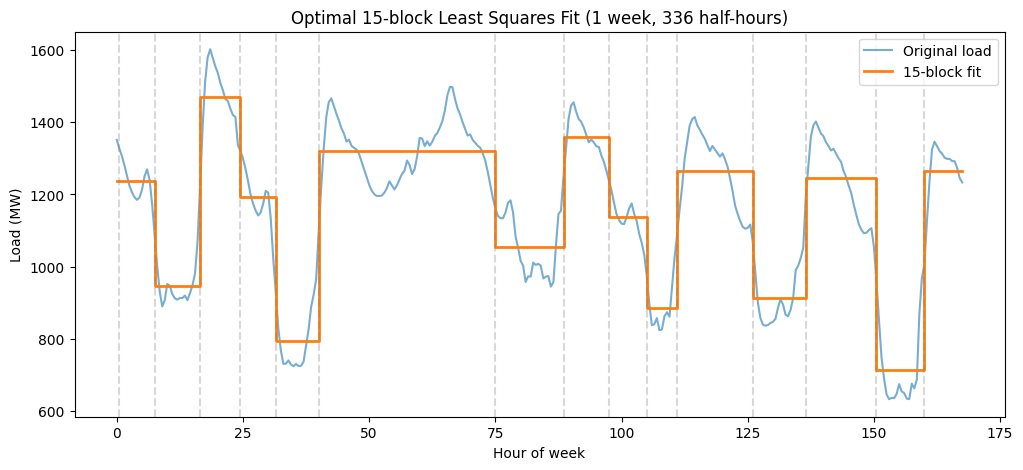

In [316]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Precompute SSE for segments
# -------------------------------
def precompute_sse(y):
    n = len(y)
    cumsum = np.insert(np.cumsum(y), 0, 0.0)
    cumsum2 = np.insert(np.cumsum(y**2), 0, 0.0)

    def sse(i, j):
        # Segment y[i:j] (0-based, j exclusive)
        length = j - i
        if length == 0:
            return 0
        sum_y = cumsum[j] - cumsum[i]
        sum_y2 = cumsum2[j] - cumsum2[i]
        mean = sum_y / length
        return sum_y2 - 2*mean*sum_y + length*mean**2

    SSE = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n+1):
            SSE[i, j-1] = sse(i, j)
    return SSE

# -------------------------------
# 2. Optimal block fitting (DP)
# -------------------------------
def optimal_blocks(y, K):
    n = len(y)
    SSE = precompute_sse(y)

    dp = np.full((K+1, n), np.inf)
    prev = np.zeros((K+1, n), dtype=int)

    # Base case: 1 block
    for t in range(n):
        dp[1, t] = SSE[0, t]

    # DP recursion
    for k in range(2, K+1):
        for t in range(k-1, n):
            best_val = np.inf
            best_s = 0
            for s in range(k-2, t):
                val = dp[k-1, s] + SSE[s+1, t]
                if val < best_val:
                    best_val = val
                    best_s = s
            dp[k, t] = best_val
            prev[k, t] = best_s

    # Traceback
    boundaries = []
    t = n-1
    for k in range(K, 0, -1):
        s = prev[k, t]
        boundaries.append((s+1, t))
        t = s
    boundaries = boundaries[::-1]

    # Build compressed series
    block_means = []
    compressed = np.zeros_like(y, dtype=float)
    for (s, e) in boundaries:
        val = y[s:e+1].mean()
        compressed[s:e+1] = val
        block_means.append(val)

    compressed[0] = compressed[1]

    return compressed, boundaries, block_means

# -------------------------------
# 3. Example with synthetic data
# -------------------------------
if __name__ == "__main__":
    np.random.seed(0)
    hours = np.arange(336) / 2  # half-hourly timestamps
    # daily_pattern = (
    #     600 + 200*np.sin(2*np.pi*hours/24) + 50*np.random.randn(len(hours))
    # )
    # load = np.clip(daily_pattern, 300, None)
    i=900
    load = tload.load.values[48*7*i:48*7*(i+1)]

    K = 15
    compressed, boundaries, block_means = optimal_blocks(load, K)

    # Compute snapshot weightings
    block_weights = [(e-s+1)/2 for (s, e) in boundaries]  # hours

    # Error metrics
    mse = np.mean((load - compressed)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(load - compressed))

    print("=== Error Metrics ===")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}\n")

    print("=== Block Summary ===")
    for i, ((s, e), val, w) in enumerate(zip(boundaries, block_means, block_weights), 1):
        print(f"Block {i:2d}: {s:3d}-{e:3d}, mean={val:7.1f} MW, weight={w:4.1f} h")

    # Plot
    plt.figure(figsize=(12,5))
    plt.plot(hours, load, label="Original load", alpha=0.6)
    plt.step(hours, compressed, where="post", label=f"{K}-block fit", linewidth=2)
    for (s, e) in boundaries:
        plt.axvline(s/2, color="grey", linestyle="--", alpha=0.3)
    plt.xlabel("Hour of week")
    plt.ylabel("Load (MW)")
    plt.title(f"Optimal {K}-block Least Squares Fit (1 week, 336 half-hours)")
    plt.legend()
    plt.show()


Maxima: 0, Minima: 1
Maxima: 1, Minima: 3
Maxima: 1, Minima: 0
Maxima: 1, Minima: 1
Maxima: 0, Minima: 1
Maxima: 2, Minima: 1
Maxima: 2, Minima: 3
Maxima: 1, Minima: 0
Maxima: 1, Minima: 1
Maxima: 0, Minima: 1
Maxima: 1, Minima: 0
Maxima: 1, Minima: 2
Maxima: 1, Minima: 1
Maxima: 0, Minima: 2
Maxima: 1, Minima: 0
Maxima: 0, Minima: 0
Maxima: 0, Minima: 1
Maxima: 1, Minima: 3
Maxima: 1, Minima: 0
Maxima: 1, Minima: 1
Maxima: 0, Minima: 1
Maxima: 2, Minima: 1
Maxima: 2, Minima: 3
Maxima: 1, Minima: 0
Maxima: 1, Minima: 1
Maxima: 0, Minima: 1
Maxima: 1, Minima: 0
Maxima: 1, Minima: 2
Maxima: 1, Minima: 1
Maxima: 0, Minima: 2
Maxima: 1, Minima: 0
Maxima: 0, Minima: 0
Maxima: 0, Minima: 1
Maxima: 1, Minima: 3
Maxima: 1, Minima: 0
Maxima: 1, Minima: 1
Maxima: 0, Minima: 1
Maxima: 2, Minima: 1
Maxima: 2, Minima: 3
Maxima: 1, Minima: 0
Maxima: 1, Minima: 1
Maxima: 0, Minima: 1
Maxima: 1, Minima: 0
Maxima: 1, Minima: 2
Maxima: 1, Minima: 1
Maxima: 0, Minima: 2
Maxima: 1, Minima: 0
Maxima: 0, Mi

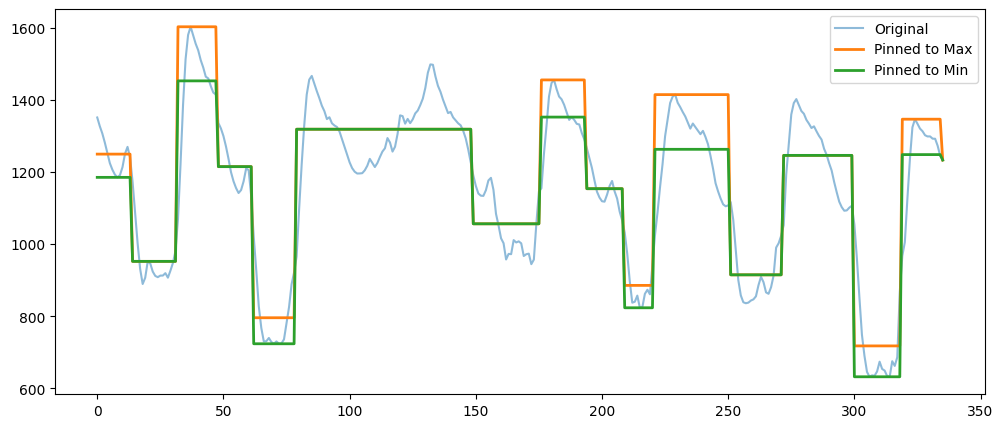

In [317]:
import numpy as np
from scipy.signal import find_peaks


def apply_peak_pinning(y, boundaries, mode="none"):
    """
    Post-process optimal blocks by pinning block values to peak max/min.

    Parameters
    ----------
    y : array
        Original time series.
    boundaries : list[int]
        List of block end indices from the optimal blocks function.
    mode : str
        "none"  -> keep block means (least squares default)
        "max"   -> pin each block to its maximum value
        "min"   -> pin each block to its minimum value

    Returns
    -------
    y_hat : array
        Compressed series with peak pinning applied.
    block_values : array
        Value assigned to each block.
    snapshot_weights : array
        Number of hours spanned by each block.
    """
    y_hat = np.zeros_like(y)
    block_values = []
    snapshot_weights = []

    start = 0
    for end in boundaries + [len(y)]:
        segment = y[start:end]

        segment_day_span = len(segment) // 12

        # x = np.linspace(-1,1,len(segment))

        # degree = min(max(2,segment_day_span*2+1),5)
        # degree=2

        # print(degree)


        # Local maxima
        peaks, _ = find_peaks(segment,width=2)

        mins, _ = find_peaks(-segment,width=2)



        print(f"Maxima: {len(peaks)}, Minima: {len(mins)}")


        # coeffs = np.polyfit(x, segment, degree)
        # p = np.poly1d(coeffs)

        # # Derivative
        # dp = p.deriv()

        # # Roots of derivative (critical points)
        # critical_points = np.roots(dp)

        # # Only real roots matter for extrema
        # real_critical_points = critical_points[np.isreal(critical_points)].real

        # # print(dp)

        # # Second Derivative
        # d2p = dp.deriv()


        # Roots of derivative (critical points)
        # critical_points_2 = np.roots(d2p)

        # Only real roots matter for extrema
        # real_critical_points_2 = critical_points_2[np.isreal(critical_points_2)].real

        # concavity = d2p()

        # fix both mode!!!

        if mode == "max" or mode=="both":
            if len(peaks)>=1 and len(mins)==0:
                block_value = np.max(segment)
            else:
                block_value = np.mean(segment)
        # else:
        #     block_value = np.mean(segment)
        elif mode == "min" or mode=="both":
            if len(peaks)==0 and len(mins)>=1:
                block_value = np.min(segment)
            else:
                block_value = np.mean(segment)
        else:
            block_value = np.mean(segment)

        y_hat[start:end] = block_value
        block_values.append(block_value)
        snapshot_weights.append((end - start) / 2)  # 2 pts = 1 hr

        start = end

    return y_hat, np.array(block_values), np.array(snapshot_weights)


# Run your optimal blocks function first:
_,boundaries,_ = optimal_blocks(load, K=15)  # for example

boundaries = [end for _,end in boundaries]

# Then apply pinning
y_hat_max, vals_max, weights_max = apply_peak_pinning(load, boundaries, mode="max")
y_hat_min, vals_min, weights_min = apply_peak_pinning(load, boundaries, mode="min")
y_hat_none, vals_none, weights_none = apply_peak_pinning(load, boundaries, mode="none")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(load, label="Original", alpha=0.5)
plt.plot(y_hat_max, label="Pinned to Max", lw=2)
plt.plot(y_hat_min, label="Pinned to Min", lw=2)
# plt.plot(y_hat_none, label="Least Squares Blocks", lw=5,zorder=3)
plt.legend()
plt.show()


In [211]:
load[:1]

array([910.143464])

In [209]:
start = 0
for end in boundaries + [len(load)]:
    segment = load[start:end]

    print(segment)

TypeError: slice indices must be integers or None or have an __index__ method

In [187]:
import numpy as np

def merge_blocks(load, n_target=15, threshold=100):
    n = len(load)
    # Start with fine segmentation: 2-hour blocks
    step = n // (n_target * 2)
    boundaries = list(range(0, n, step))
    if boundaries[-1] != n:
        boundaries.append(n)
    
    # Compute initial block values
    blocks = []
    for i in range(len(boundaries)-1):
        s, e = boundaries[i], boundaries[i+1]
        val = load[s:e].mean()
        hours = (e-s)/2
        blocks.append({"s":s, "e":e, "val":val, "hours":hours})

    # Iteratively merge until we reach n_target blocks
    while len(blocks) > n_target:
        # Find smallest difference between adjacent blocks
        diffs = [abs(blocks[i]["val"] - blocks[i+1]["val"]) for i in range(len(blocks)-1)]
        i_min = int(np.argmin(diffs))
        
        # If difference is small enough, merge
        if diffs[i_min] < threshold or len(blocks) > n_target:
            b1, b2 = blocks[i_min], blocks[i_min+1]
            new_hours = b1["hours"] + b2["hours"]
            new_val = (b1["val"]*b1["hours"] + b2["val"]*b2["hours"]) / new_hours
            new_block = {"s":b1["s"], "e":b2["e"], "val":new_val, "hours":new_hours}
            blocks[i_min:i_min+2] = [new_block]
        else:
            break

    # Build compressed series
    compressed = np.zeros_like(load)
    for b in blocks:
        compressed[b["s"]:b["e"]] = b["val"]

    return compressed, blocks

load = tload.load.values[:48*7]

compressed, blocks = merge_blocks(load,15,100)


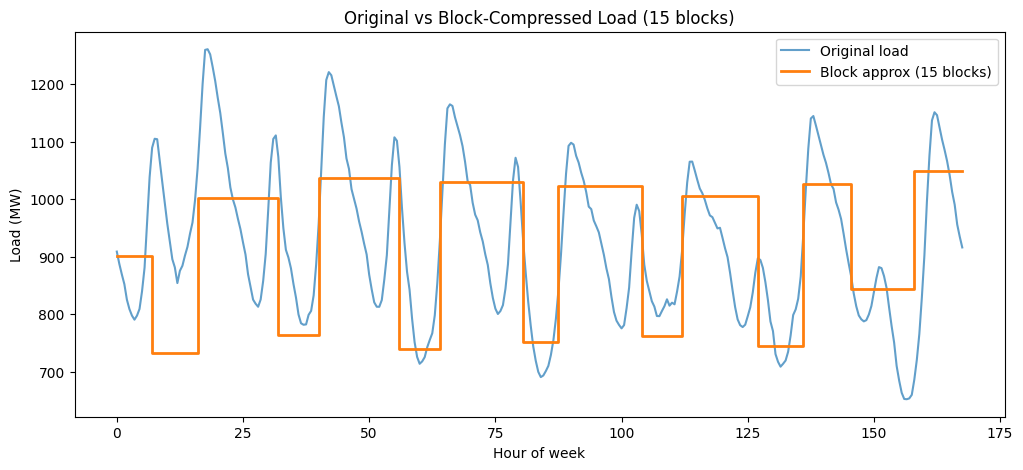

=== Error Metrics ===
MSE:  16635.06
RMSE: 128.98
MAE:  101.78



In [305]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- 1. Create synthetic weekly demand data (48*7 = 336 points) ---
# np.random.seed(0)
hours = np.arange(len(load[:48*7])) / 2  # half-hourly timestamps (in hours)
# daily_pattern = (
#     500 + 200*np.sin(2*np.pi*hours/24) + 50*np.random.randn(len(hours))
# )
# load = np.clip(daily_pattern, 300, None)

# --- 2. Function to compress load into blocks ---
def fit_blocks(load, n_blocks=15, seed_hours=None):
    """
    Approximate load with n_blocks of variable length.
    """
    n = len(load)
    # Initial guess: split series into equal chunks
    boundaries = np.linspace(0, n, n_blocks+1, dtype=int)

    block_values = []
    block_hours = []
    compressed = np.zeros_like(load)

    for i in range(n_blocks):
        s, e = boundaries[i], boundaries[i+1]
        val = load[s:e].mean()
        compressed[s:e] = val
        block_values.append(val)
        block_hours.append((e-s)/2)  # half-hours → hours

    return np.array(compressed), np.array(block_values), np.array(block_hours), boundaries

# --- 3. Run block fitting ---
# compressed, block_values, block_hours, boundaries = fit_blocks(load.iloc[:48*7], n_blocks=15)

load = tload.load.values[:48*7]

# --- 4. Plot original vs compressed ---
plt.figure(figsize=(12,5))
plt.plot(hours, tload.iloc[:48*7], label="Original load", alpha=0.7)
plt.step(hours, compressed, where="post", label="Block approx (15 blocks)", linewidth=2)


# # Show block boundaries
# for b in boundaries:
#     plt.axvline(b/2, color="grey", linestyle="--", alpha=0.4)

plt.xlabel("Hour of week")
plt.ylabel("Load (MW)")
plt.title("Original vs Block-Compressed Load (15 blocks)")
plt.legend()
plt.show()

 # Error metrics
mse = np.mean((load - compressed)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(load - compressed))

print("=== Error Metrics ===")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}\n")

# --- 5. Print block summary ---
# print("Block values (MW):", np.round(block_values,1))
# print("Block weights (hours):", block_hours)
# print("Check sum of weights = ", block_hours.sum(), "hours (should be 168)")


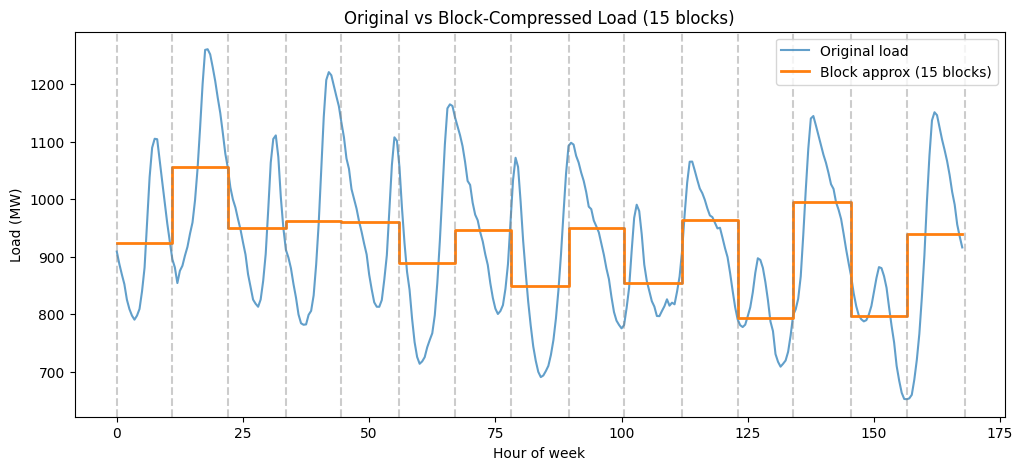

=== Error Metrics ===
MSE:  13337.36
RMSE: 115.49
MAE:  94.96

Block values (MW): [ 924.3 1054.9  949.9  962.5  960.5  888.3  946.6  848.7  949.4  853.9
  964.   793.1  994.3  796.6  939.4]
Block weights (hours): [11.  11.  11.5 11.  11.5 11.  11.  11.5 11.  11.5 11.  11.  11.5 11.
 11.5]
Check sum of weights =  168.0 hours (should be 168)


In [191]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- 1. Create synthetic weekly demand data (48*7 = 336 points) ---
# np.random.seed(0)
hours = np.arange(len(load[:48*7])) / 2  # half-hourly timestamps (in hours)
# daily_pattern = (
#     500 + 200*np.sin(2*np.pi*hours/24) + 50*np.random.randn(len(hours))
# )
# load = np.clip(daily_pattern, 300, None)

# --- 2. Function to compress load into blocks ---
def fit_blocks(load, n_blocks=15, seed_hours=None):
    """
    Approximate load with n_blocks of variable length.
    """
    n = len(load)
    # Initial guess: split series into equal chunks
    boundaries = np.linspace(0, n, n_blocks+1, dtype=int)

    block_values = []
    block_hours = []
    compressed = np.zeros_like(load)

    for i in range(n_blocks):
        s, e = boundaries[i], boundaries[i+1]
        val = load[s:e].mean()
        compressed[s:e] = val
        block_values.append(val)
        block_hours.append((e-s)/2)  # half-hours → hours

    return np.array(compressed), np.array(block_values), np.array(block_hours), boundaries

# --- 3. Run block fitting ---
compressed, block_values, block_hours, boundaries = fit_blocks(load, n_blocks=15)

# --- 4. Plot original vs compressed ---
plt.figure(figsize=(12,5))
plt.plot(hours, load, label="Original load", alpha=0.7)
plt.step(hours, compressed, where="post", label="Block approx (15 blocks)", linewidth=2)

# Show block boundaries
for b in boundaries:
    plt.axvline(b/2, color="grey", linestyle="--", alpha=0.4)

plt.xlabel("Hour of week")
plt.ylabel("Load (MW)")
plt.title("Original vs Block-Compressed Load (15 blocks)")
plt.legend()
plt.show()

 # Error metrics
mse = np.mean((load - compressed)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(load - compressed))

print("=== Error Metrics ===")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}\n")

# --- 5. Print block summary ---
print("Block values (MW):", np.round(block_values,1))
print("Block weights (hours):", block_hours)
print("Check sum of weights = ", block_hours.sum(), "hours (should be 168)")


In [58]:
x = load.iloc[:48*7*3]

In [81]:
x

,load
2024-07-01 00:00:00,908.804753
2024-07-01 00:30:00,887.390546
2024-07-01 01:00:00,869.077990
2024-07-01 01:30:00,852.119366
2024-07-01 02:00:00,825.258818
...,...
2024-07-21 21:30:00,1073.660228
2024-07-21 22:00:00,1049.052640
2024-07-21 22:30:00,1013.475941
2024-07-21 23:00:00,988.741581


In [82]:
compressed, block_values, block_hours, boundaries = fit_blocks(x, n_blocks=15)


<Axes: >

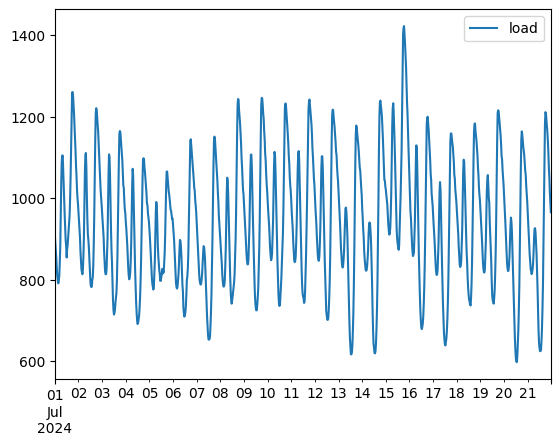

In [60]:
x.plot()

In [61]:
sol = compress_multi_year(x)

In [72]:
import numpy as np
import matplotlib.pyplot as plt

ValueError: x and y must have same first dimension, but have shapes (1008,) and (45,)

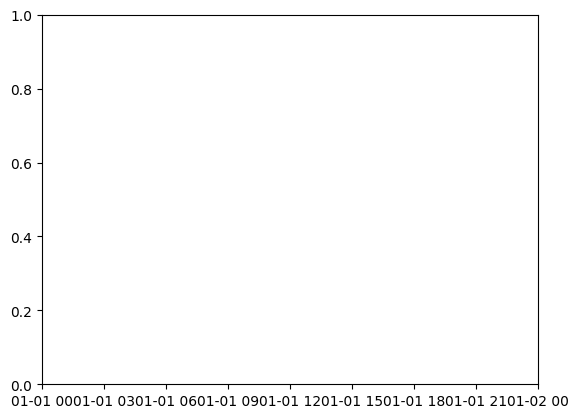

In [73]:
plt.plot(x.index, np.array(np.array(sol["block_values"]).flatten()))

In [ ]:
sol["compressed_series"].plot(

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

In [62]:
sol["block_weights"]

[array([ 6. , 10.5,  7. , 16.5,  6.5, 11.5,  6.5,  8. ,  9.5,  6. ,  7. ,
        41. , 17.5,  7. ,  7.5]),
 array([16. ,  6.5, 11.5,  6. ,  6.5, 17.5, 42. ,  6.5,  9.5,  8.5,  6. ,
         7.5, 10. ,  7. ,  7. ]),
 array([16.5,  5. ,  3. , 33. ,  7. ,  6.5, 36. ,  5.5,  9.5,  8. ,  6.5,
         7.5,  9.5,  7.5,  7. ])]

In [128]:
load.columns = ["load"]

In [28]:
load[:48*3].tail()

,0
2024-07-03 21:30:00,1031.549891
2024-07-03 22:00:00,1024.595202
2024-07-03 22:30:00,993.693025
2024-07-03 23:00:00,972.947111
2024-07-03 23:30:00,963.211751


In [6]:
df = pd.read_csv("../Traces/SC/demand/CNSW_RefYear_4006_STEP_CHANGE_POE10_OPSO_MODELLING.csv")

In [16]:
dates = pd.date_range("2024-07-01 00:00","2053-06-30 23:30",freq="30min")

In [173]:
tload = pd.DataFrame(data=x,index=dates)

In [176]:
tload.columns = ["load"]

In [15]:
df.tail()

,Year,Month,Day,01,02,03,04,05,06,07,...,39,40,41,42,43,44,45,46,47,48
10587,2053,6,26,1566.125607,1541.690611,1519.643174,1482.822682,1440.301462,1397.411566,1360.369918,...,1818.423718,1804.950882,1791.156343,1769.409712,1740.041540,1693.616466,1675.783903,1631.029994,1597.993187,1578.051969
10588,2053,6,27,1553.693688,1528.230165,1506.941390,1471.496525,1429.761210,1391.659316,1352.933705,...,1719.745711,1708.129623,1699.626122,1676.646590,1658.293105,1630.786359,1623.822286,1589.974923,1569.118766,1551.172104
10589,2053,6,28,1552.875982,1530.590772,1509.455707,1471.218017,1430.582962,1390.232054,1351.768671,...,1672.701597,1653.256594,1641.989112,1626.543593,1613.303054,1589.333612,1582.091253,1551.910982,1540.739602,1534.913644
10590,2053,6,29,1513.489399,1508.611670,1501.463876,1486.811180,1450.421433,1408.718313,1370.699537,...,1846.867742,1823.464862,1806.295321,1776.100071,1734.546347,1695.361139,1671.164997,1619.689338,1588.916190,1560.065263
10591,2053,6,30,1497.652803,1473.552634,1459.506383,1443.679115,1429.585343,1419.770478,1411.492343,...,1901.946711,1875.922540,1844.221355,1810.007519,1767.709480,1718.972766,1692.186447,1643.116992,1611.590244,1596.812447


In [124]:
x = df.set_index(["Year","Month","Day"]).values.flatten()

In [6]:
# ...existing code...
network = pypsa.Network("../networks/isp24_v2.nc")
# ...existing code...

INFO:pypsa.io:Imported network isp24_v2.nc has buses, carriers, generators, links, loads, storage_units, transformers


In [4]:
network

PyPSA Network
Components:
 - Bus: 12
 - Carrier: 10
 - Generator: 446
 - Link: 14
 - Load: 12
 - StorageUnit: 20
 - Transformer: 6
Snapshots: 96

In [14]:
network.carriers.isin(['Black Coal','Brown Coal','Gas','Liquid Fuel'])

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
Black Coal,False,False,False,False,False
Brown Coal,False,False,False,False,False
Gas,False,False,False,False,False
Liquid Fuel,False,False,False,False,False
Water,False,False,False,False,False
Solar,False,False,False,False,False
Wind,False,False,False,False,False
Battery,False,False,False,False,False
AC,False,False,False,False,False


In [17]:
network.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
Bayswater (BW01),CNSW,Slack,,660.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,660.0
Bayswater (BW02),CNSW,PQ,,685.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,685.0
Bayswater (BW03),CNSW,PQ,,685.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,685.0
Bayswater (BW04),CNSW,PQ,,685.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,685.0
Callide B (CALL_B_1),CQ,Slack,,325.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,325.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Woodlawn Wind Farm (WOODLWN1),SNSW,PQ,,48.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,48.0
Woolnorth Wind Farm (WOOLNTH1),TAS,PQ,,140.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,140.0
Yaloak South Wind Farm (YSWF1),VIC,PQ,,29.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,29.0


In [20]:
network.generators[network.generators.carrier.isin(['Black Coal','Brown Coal','Gas','Liquid Fuel'])].shape[0]

175

In [26]:
network.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
Link,,,,,,,,,,,,,,,,,,,,,
CQ-NQ,CQ,NQ,,AC,1.0,True,0,inf,1400.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1400.0
CQ-GG,CQ,GG,,AC,1.0,True,0,inf,1050.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1050.0
SQ-CQ,SQ,CQ,,AC,1.0,True,0,inf,1100.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1100.0
NNSW-SQ QNI,NNSW,SQ,,AC,1.0,True,0,inf,745.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,745.0
NNSW-SQ Terranora,NNSW,SQ,,DC,1.0,True,0,inf,50.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,50.0
CNSW–NNSW QNI,CNSW,NNSW,,AC,1.0,True,0,inf,910.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,910.0
CNSW­–SNW North,CNSW,SNW,,AC,1.0,True,0,inf,4730.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,4730.0
CNSW–SNW South,CNSW,SNW,,AC,1.0,True,0,inf,2720.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,2720.0
SNSW–CNSW VNI,SNSW,CNSW,,AC,1.0,True,0,inf,2950.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,2950.0


In [5]:
model = network.optimize.create_model()
network.optimize.solve_model(
    solver_name="gurobi",
    solver_options={"LogFile": "../gurobi.log"}
)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - LogFile: ../gurobi.log
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 74.28it/s]
INFO:linopy.io: Writing time: 0.59s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


INFO:gurobipy:Set parameter WLSSecret


...

INFO:gurobipy:Solved in 5237 iterations and 0.37 seconds (0.13 work units)


Optimal objective  2.267691239e+07


INFO:gurobipy:Optimal objective  2.267691239e+07


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 50496 primals, 104160 duals
Objective: 2.27e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [30]:
model.variables['Link-p']

Variable (snapshot: 96, Link: 14)
---------------------------------
[2025-01-01 00:00:00, CQ-NQ]: Link-p[2025-01-01 00:00:00, CQ-NQ] ∈ [-inf, inf]
[2025-01-01 00:00:00, CQ-GG]: Link-p[2025-01-01 00:00:00, CQ-GG] ∈ [-inf, inf]
[2025-01-01 00:00:00, SQ-CQ]: Link-p[2025-01-01 00:00:00, SQ-CQ] ∈ [-inf, inf]
[2025-01-01 00:00:00, NNSW-SQ QNI]: Link-p[2025-01-01 00:00:00, NNSW-SQ QNI] ∈ [-inf, inf]
[2025-01-01 00:00:00, NNSW-SQ Terranora]: Link-p[2025-01-01 00:00:00, NNSW-SQ Terranora] ∈ [-inf, inf]
[2025-01-01 00:00:00, CNSW–NNSW QNI]: Link-p[2025-01-01 00:00:00, CNSW–NNSW QNI] ∈ [-inf, inf]
[2025-01-01 00:00:00, CNSW­–SNW North]: Link-p[2025-01-01 00:00:00, CNSW­–SNW North] ∈ [-inf, inf]
		...
[2025-01-02 23:30:00, CNSW–SNW South]: Link-p[2025-01-02 23:30:00, CNSW–SNW South] ∈ [-inf, inf]
[2025-01-02 23:30:00, SNSW–CNSW VNI]: Link-p[2025-01-02 23:30:00, SNSW–CNSW VNI] ∈ [-inf, inf]
[2025-01-02 23:30:00, VIC–SNSW VNI]: Link-p[2025-01-02 23:30:00, VIC–SNSW VNI] ∈ [-inf, inf]
[2025-01-02 23:3

In [7]:
import pypsa 
import pandas as pd

n = pypsa.Network()

years = list(range(2024,2056))
freq = "3"
snapshots = pd.DatetimeIndex([])
period = pd.date_range(
    start="2024-07-01 00:00",
    end="2055-06-30 00:00",
    freq=f"{freq}h"
    # periods=8760 / float(freq),
)
snapshots = snapshots.append(period)

# convert to multiindex and assign to network
n.snapshots = pd.MultiIndex.from_arrays([snapshots.year, snapshots])
n.investment_periods = years

In [21]:
# apply timeslice mask to capacity and cost
import pandas as pd 

def _get_timeslices(tpath="../Traces/timeslice_RefYear4006.csv",
                    start=(2024,7,1),
                    end  =(2055,6,30)):
    "return type of day for all days in the traces provided"

    # get timeslice df
    df = pd.read_csv(tpath)
    timeslice = {}
    regions = ("NSW","QLD","VIC","TAS","SA")

    day_type_map = {
        "Hot Day" : "SP",
        "Typical Summer" : "ST",
        "Winter" : "W"
    }

    # group timeslices by regions
    for region in regions:
        timeslice[region] = df[df.NAME.str.startswith(region)].copy()

    # create timeslice mask
    for region in regions:

        df = timeslice[region]

        df = df[df["TIMESLICE"]==-1].loc[:]

        # Ensure proper datetime
        df["DATETIME"] = pd.to_datetime(df["DATETIME"], dayfirst=True)

        # Sort by date
        df = df.sort_values("DATETIME").reset_index(drop=True)

        # Add "NEXT" column = next start date
        df["NEXT"] = df["DATETIME"].shift(-1)

        # Type of day compatible with data (ST, SP, or W)
        df["DAY_TYPE"] = df["NAME"].str.split(" ").str[1:].str.join(" ")
        df["DAY_TYPE_SHORT"] = df["DAY_TYPE"].map(day_type_map)

        # Expand each range into daily rows
        blocks = []
        for _, row in df.iterrows():
            start = row["DATETIME"]
            next_date = row["NEXT"]

            # If no next date, just keep the start
            end = start if pd.isna(next_date) else next_date - pd.Timedelta(days=1)

            # Generate daily range
            rng = pd.date_range(start, end, freq="D")
            block = pd.DataFrame({"DATETIME": rng, "DAY_TYPE": row["DAY_TYPE"], "DAY_TYPE_SHORT": row["DAY_TYPE_SHORT"]})
            blocks.append(block)

        out = pd.concat(blocks, ignore_index=True)

        timeslice[region] = out.set_index("DATETIME").sort_index().copy()
    
    return regions,timeslice

def _region_timeslice(region,timeslice):
    "From timeslice for a region get day_type and day_type_short"

    # NAME and DAY_TYPE
    return timeslice[region].copy()

regions,tdf = _get_timeslices()



nsw_ts = _region_timeslice('QLD',tdf)

print(nsw_ts)

# combine days to seasonal ratings and outages

cap = pd.read_csv("../isp_sheets_23/seasonal_ratings/existing_gen_seasonal_ratings.csv")

print(cap)

# snapshots

years = list(range(2024,2056))
freq = "3"
snapshots = pd.DatetimeIndex([])
period = pd.date_range(
    start="2031-07-01 00:00",
    end="2033-07-30 23:30",
    freq=f"{freq}h"
    # periods=8760 / float(freq),
)
snapshots = snapshots.append(period)

                  DAY_TYPE DAY_TYPE_SHORT
DATETIME                                 
2021-06-30          Winter              W
2021-07-01          Winter              W
2021-07-02          Winter              W
2021-07-03          Winter              W
2021-07-04          Winter              W
...                    ...            ...
2058-03-28  Typical Summer             ST
2058-03-29  Typical Summer             ST
2058-03-30  Typical Summer             ST
2058-03-31  Typical Summer             ST
2058-04-01          Winter              W

[13425 rows x 2 columns]
                  Generator      DUID Region  SP2023-24  SP2024-25  SP2025-26  \
0                 Bayswater      BW01    NSW        630        630        630   
1                 Bayswater      BW02    NSW        655        655        655   
2                 Bayswater      BW03    NSW        655        655        655   
3                 Bayswater      BW04    NSW        655        655        655   
4                 Calli

In [24]:
import pandas as pd

nsw_map = nsw_ts.DAY_TYPE_SHORT.to_dict()

snapshots_day = snapshots.strftime("%Y-%m-%d")

snapshots_day_dt = pd.to_datetime(snapshots_day)
day_types = snapshots_day_dt.map(lambda d: nsw_map.get(d, None))
years = snapshots_day_dt.year
fin_years = years.where(snapshots_day_dt.month < 7, years + 1)

cap_cols = []

for (dt, fy), y in zip(zip(day_types, fin_years),years):
    if dt == 'W':
        if y <= 2032:
            cap_cols.append(f"{dt}{y}")
        else:
            cap_cols.append(f"{dt}2032")
    else:
        if fy <= 2033:
            cap_cols.append(f"{dt}{fy-1}-{str(fy)[-2:]}")
        else:
            cap_cols.append(f"{dt}2032-33")

# # Find the last available column in cap (e.g., 'W2032-33')
# last_col = sorted([col for col in cap.columns if col[-5:] == '32-33'])[-1] if any(col[-5:] == '32-33' for col in cap.columns) else cap.columns[-1]

# Select the row for the desired DUID
cap_row = cap[cap["DUID"] == "KPP_1"].iloc[0]

# Build the capacity list, using last_col if the column is missing
capacity_list = [
    cap_row[col] # if col in cap_row.index else cap_row[last_col]
    for col in cap_cols
]

<Axes: >

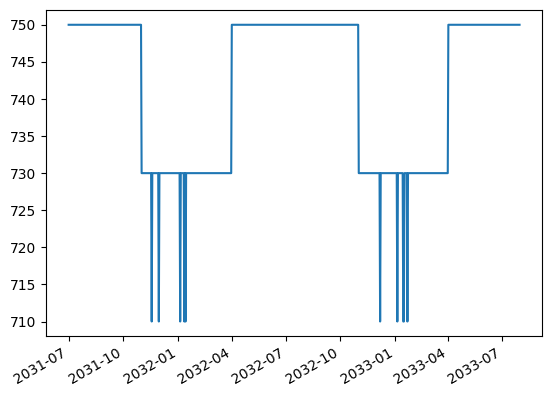

In [25]:
capacity_series = pd.Series(capacity_list, index=snapshots_day_dt)
capacity_series.plot()